# Vehicle View Classifier — Demo Notebook

Personal research demo. Given a vehicle photo, the model predicts:

- an **8-way view** (`front`, `front_right`, … `front_left`)
- a **continuous azimuth** (0° = front, clockwise, 90° = right)
- a **confidence** score

**Audience:** walkthrough for stakeholders / collaborators  
**Needs:** local checkpoint at `models/joint_v2_best.pt` (or `artifacts/.../view_classifier_best.pt`) and sample images in `docs/demo_images/`.

Prefer a live UI? Run the Gradio app instead:

```bash
PYTHONPATH=. .venv/bin/python -m view_classifier.app
```

## 1. Setup

Run from the **repo root** (or adjust `REPO` below).

In [1]:
from __future__ import annotations

import io
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image, display
from PIL import Image as PILImage

REPO = Path.cwd()
if not (REPO / "view_classifier").exists():
    # notebook opened from notebooks/
    REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

from view_classifier.labels import POSE_CLASSES
from view_classifier.predict import (
    DEFAULT_CKPT,
    DEMO_IMAGE_DIR,
    format_prediction,
    list_demo_images,
    predict_image,
)


def show_fig(fig, dpi=120):
    """Embed a matplotlib figure as PNG in the notebook output (survives Save)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=dpi)
    plt.close(fig)
    display(Image(data=buf.getvalue()))


print("repo:", REPO)
print("ckpt exists:", DEFAULT_CKPT.exists(), DEFAULT_CKPT)
print("demo images:", len(list_demo_images()), DEMO_IMAGE_DIR)


repo: /Users/rakesh.pandey/Projects/damaged_ai/view_classifier
ckpt exists: True /Users/rakesh.pandey/Projects/damaged_ai/view_classifier/models/joint_v2_best.pt
demo images: 12 /Users/rakesh.pandey/Projects/damaged_ai/view_classifier/docs/demo_images


## 2. Angle convention (quick reminder)

| Angle | Meaning |
|---|---|
| 0° | Front |
| 90° | Right (passenger side on LHD) |
| 180° | Rear |
| 270° | Left |

Eight pose bins are 45° wide around those compass points.

## 3. Predict one sample photo

Pick any image from `docs/demo_images/` (real Wikimedia damage photos).

01_wiki_00050_Vehicle_After_a_Side-Impact_C.jpg
**View:** `left`

**Angle:** `295.9°`  (0°=front, clockwise, 90°=right)

**Confidence:** `88.2%`

_Checkpoint epoch 10_


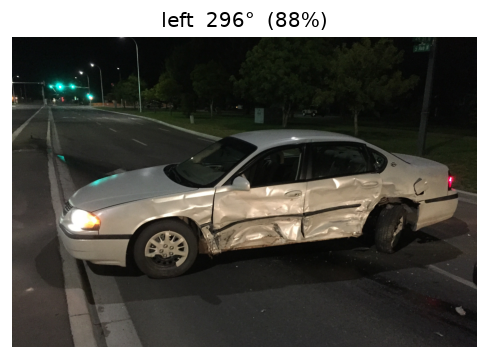

In [2]:
samples = list_demo_images()
assert samples, f"No images in {DEMO_IMAGE_DIR}"
path = samples[0]
image = PILImage.open(path).convert("RGB")

result = predict_image(image)
print(path.name)
print(format_prediction(result))

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(image)
ax.set_title(f"{result['pred']}  {result['pred_ang']:.0f}°  ({result['conf']:.0%})")
ax.axis("off")
show_fig(fig)


## 4. Gallery — all demo photos

Green title = confidence ≥ 60%. Amber = 35–60%. Red = &lt; 35% (often close-ups or extreme wrecks).

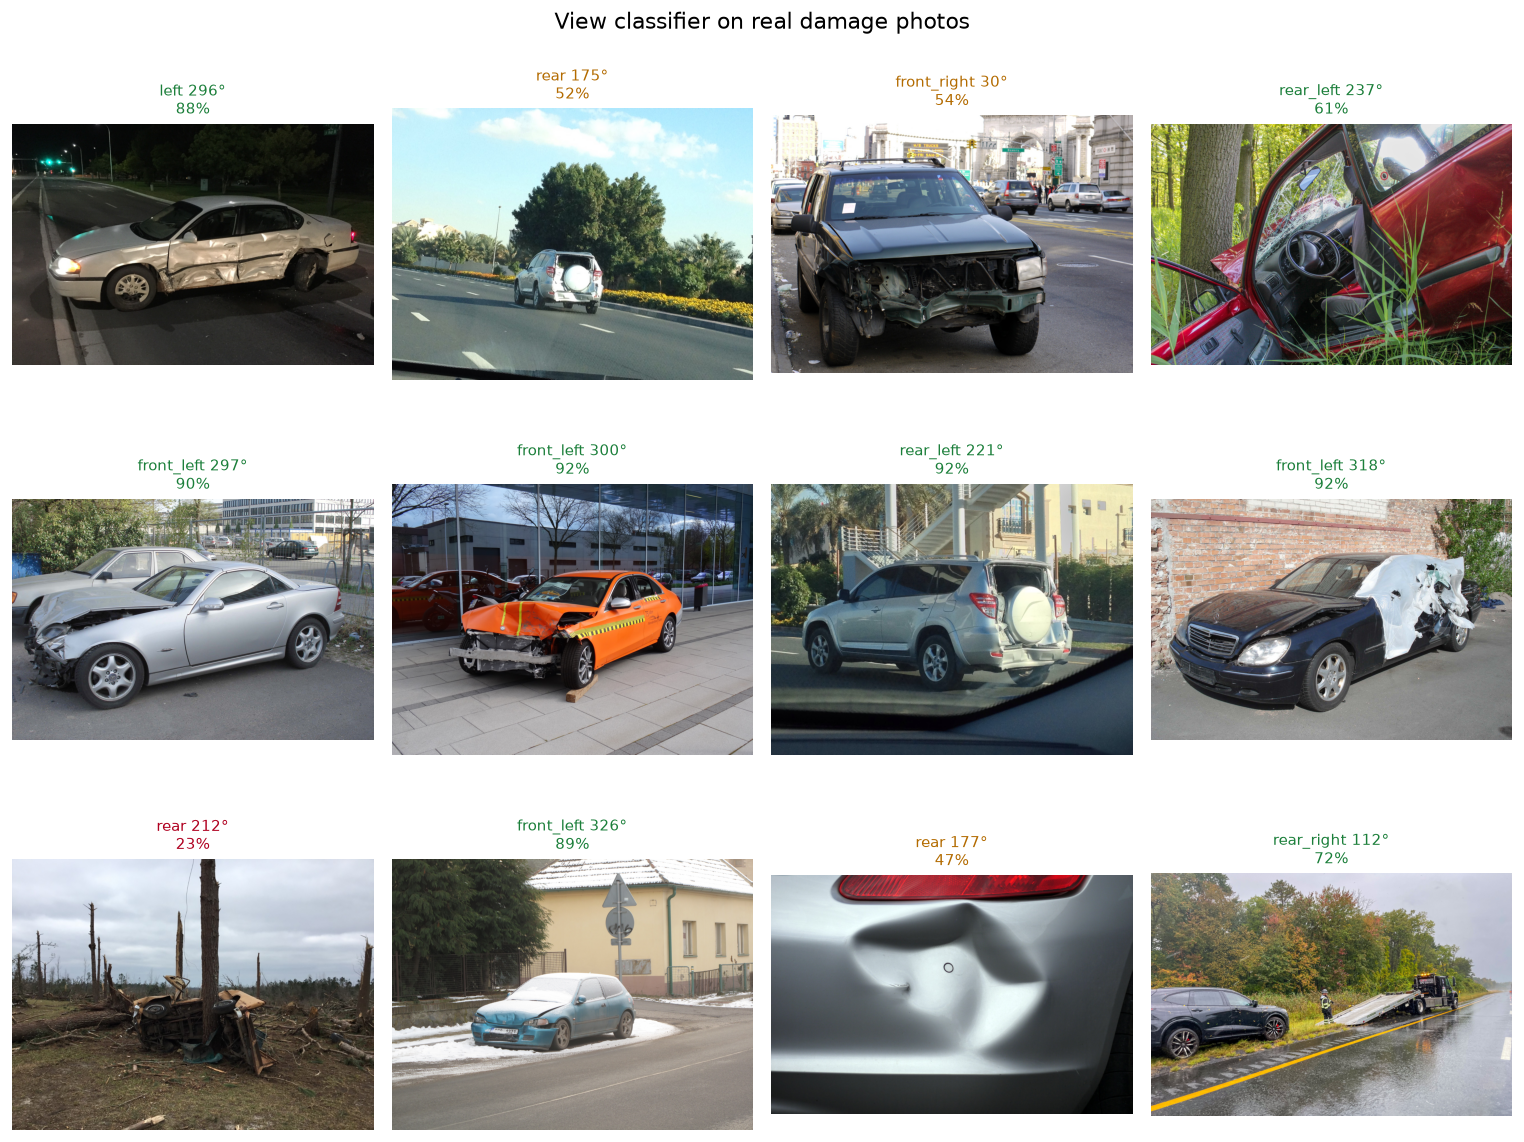

In [3]:
paths = list_demo_images()
cols = 4
rows = (len(paths) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.4 * rows))
axes = axes.flatten()

for ax, path in zip(axes, paths):
    image = PILImage.open(path).convert("RGB")
    pred = predict_image(image)
    conf = pred["conf"]
    color = "#1b7f3a" if conf >= 0.6 else "#b36b00" if conf >= 0.35 else "#b00020"
    ax.imshow(image)
    ax.set_title(
        f"{pred['pred']} {pred['pred_ang']:.0f}°\n{conf:.0%}",
        color=color,
        fontsize=9,
    )
    ax.axis("off")

for ax in axes[len(paths):]:
    ax.axis("off")

fig.suptitle("View classifier on real damage photos", fontsize=13)
fig.tight_layout()
show_fig(fig)


## 5. Class probabilities for one image

Useful when confidence is mid/low — shows whether the model is torn between adjacent views.

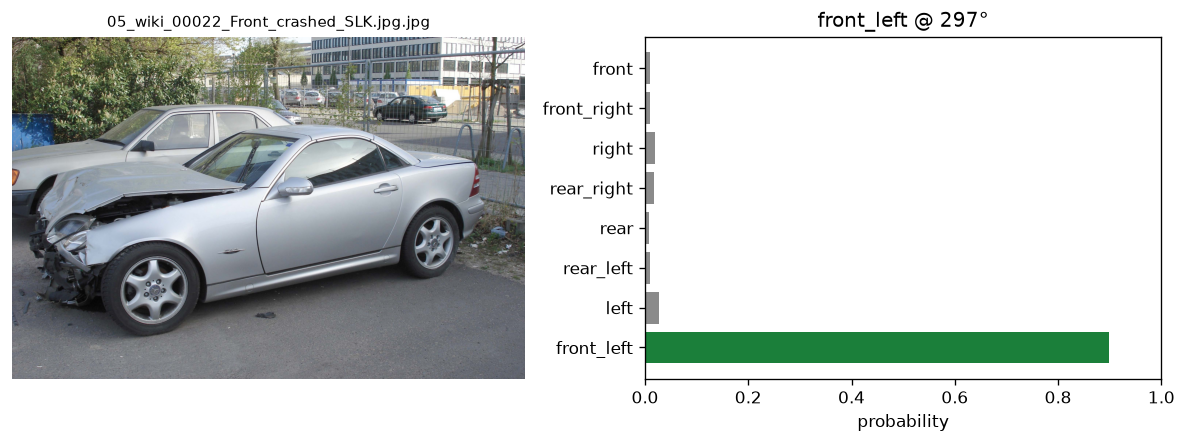

{'pred': 'front_left',
 'pred_ang': 296.6,
 'conf': 0.898,
 'probs': {'front': 0.009,
  'front_right': 0.0105,
  'right': 0.0194,
  'rear_right': 0.0177,
  'rear': 0.0086,
  'rear_left': 0.0094,
  'left': 0.027,
  'front_left': 0.8984},
 'ckpt_epoch': 10,
 'classes': ['front',
  'front_right',
  'right',
  'rear_right',
  'rear',
  'rear_left',
  'left',
  'front_left']}

In [4]:
path = samples[min(4, len(samples) - 1)]
image = PILImage.open(path).convert("RGB")
pred = predict_image(image)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].imshow(image)
axes[0].set_title(path.name, fontsize=9)
axes[0].axis("off")

names = list(POSE_CLASSES)
vals = [pred["probs"][n] for n in names]
colors = ["#1b7f3a" if v == max(vals) else "#8a8a8a" for v in vals]
axes[1].barh(names[::-1], vals[::-1], color=colors[::-1])
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("probability")
axes[1].set_title(f"{pred['pred']} @ {pred['pred_ang']:.0f}°")
fig.tight_layout()
show_fig(fig)
pred


## 6. Try your own photo

Change `YOUR_PHOTO` to a local path and re-run.

In [5]:
YOUR_PHOTO = None  # e.g. Path("/path/to/photo.jpg")

if YOUR_PHOTO is not None:
    image = PILImage.open(YOUR_PHOTO).convert("RGB")
    pred = predict_image(image)
    display(image.resize((480, 360)))
    print(format_prediction(pred))
else:
    print("Set YOUR_PHOTO to a file path to run custom inference.")


Set YOUR_PHOTO to a file path to run custom inference.


## Takeaways

- Wide exterior shots → usually high confidence and a sensible view.
- Extreme wrecks / tight close-ups → confidence drops (good signal).
- Documents / non-vehicle frames need a separate utility gate (not this model).

More numbers: `docs/RESULTS.md`. Live UI: `python -m view_classifier.app`.